In [ ]:
# Course : CS 513- Data Analytics & Machine Learning
# First Name : Christopher
# Last Name : Kang
# Id : 20006194
# HW: Final Project
# purpose : The code for the final project

In [11]:
import pandas as pd
from io import StringIO


# Load into DataFrame (assuming tab-separated)
df = pd.read_csv('Student Insomnia and Educational Outcomes Dataset_version-2.csv')

# Clean column names: Remove numbers and prefixes for simplicity
df.columns = [
    'Timestamp',
    'Year of Study',
    'Gender',
    'Difficulty Falling Asleep',
    'Hours of Sleep',
    'Waking Up at Night',
    'Sleep Quality',
    'Difficulty Concentrating',
    'Daytime Fatigue',
    'Missing Classes',
    'Impact on Assignments',
    'Electronic Devices Before Sleep',
    'Caffeine Consumption',
    'Physical Activity',
    'Stress Levels',
    'Academic Performance'
]

# Note: For categorical treatment, we keep the original string values and handle encoding in the modeling step.
# No numerical mappings or conversions needed here for features, as we'll treat them as categorical.

# Handle any NaN (if any in a larger dataset)
df.fillna('Unknown', inplace=True)  # Simple imputation for categorical; adjust as needed

# Display the first few rows
print(df.head())

             Timestamp     Year of Study  Gender  \
0  10/24/2024 16:51:15  Graduate student    Male   
1  10/24/2024 16:51:51        Third year    Male   
2  10/24/2024 16:52:21        First year  Female   
3  10/24/2024 16:53:00        Third year    Male   
4  10/24/2024 16:53:25  Graduate student    Male   

      Difficulty Falling Asleep     Hours of Sleep  \
0      Often (5-6 times a week)          7-8 hours   
1      Often (5-6 times a week)          7-8 hours   
2  Sometimes (3-4 times a week)          7-8 hours   
3      Often (5-6 times a week)  More than 8 hours   
4      Often (5-6 times a week)          7-8 hours   

             Waking Up at Night Sleep Quality Difficulty Concentrating  \
0      Often (5-6 times a week)          Good                Sometimes   
1      Often (5-6 times a week)          Good                    Often   
2  Sometimes (3-4 times a week)          Good                    Often   
3  Sometimes (3-4 times a week)          Poor                    O

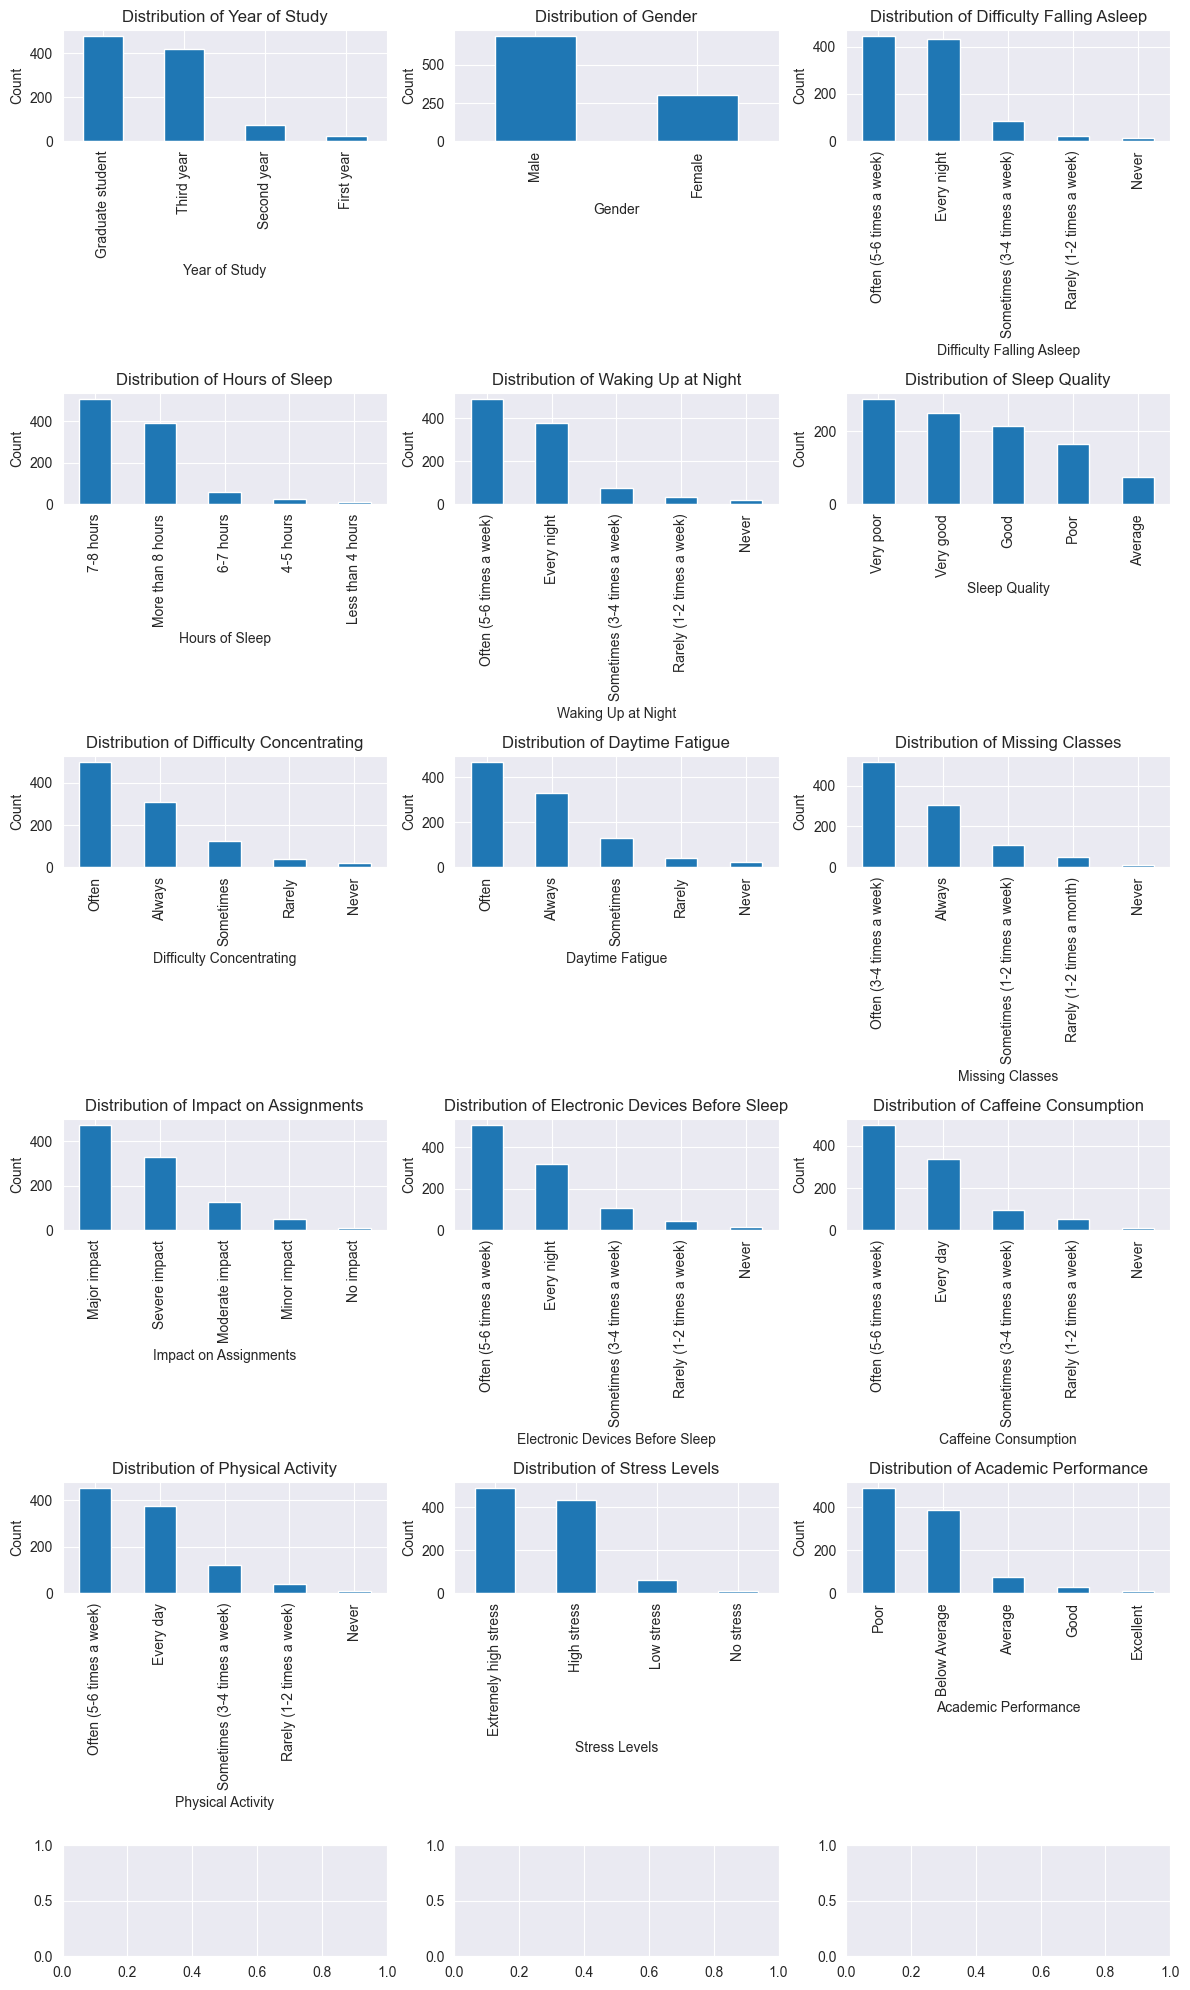

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# For categorical variables, use bar plots instead of histograms
cat_cols = [
    'Year of Study',
    'Gender',
    'Difficulty Falling Asleep',
    'Hours of Sleep',
    'Waking Up at Night',
    'Sleep Quality',
    'Difficulty Concentrating',
    'Daytime Fatigue',
    'Missing Classes',
    'Impact on Assignments',
    'Electronic Devices Before Sleep',
    'Caffeine Consumption',
    'Physical Activity',
    'Stress Levels',
    'Academic Performance'
]

# Plot bar charts for each categorical column
fig, axes = plt.subplots(nrows=len(cat_cols)//3 + 1, ncols=3, figsize=(12, 20))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_ylabel('Count')
plt.tight_layout()
plt.show()

# For correlations, since all are categorical, we can use Cramer's V or similar, but for simplicity, skip or use a different approach.
# If needed, you can compute associations, but the original heatmap was for numerical; here, we omit it.

In [13]:
from xgboost import XGBClassifier
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
import numpy as np

# For Neural Network (if using)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from scikeras.wrappers import KerasClassifier

# Uncomment if using XGBoost
# from xgboost import XGBClassifier

# Assuming df is the preprocessed DataFrame from the previous code
# If not, load it: df = pd.read_csv('preprocessed_survey_data.csv')

# Identify columns
target = 'Academic Performance'
performance_mapping = {
    'Poor': 0,
    'Below Average': 1,
    'Average': 2,
    'Good': 3,
    'Excellent': 4
}
df['Academic Performance Encoded'] = df['Academic Performance'].map(performance_mapping)
target = 'Academic Performance Encoded'

# Drop rows where the target is NaN
df = df.dropna(subset=[target])

# Check if we have enough data for modeling
if len(df) < 5:
    print(f"Dataset too small ({len(df)} rows). Skipping modeling. Load a larger dataset for meaningful results.")
else:
    cat_cols = [
        'Year of Study',
        'Gender',
        'Difficulty Falling Asleep',
        'Hours of Sleep',
        'Waking Up at Night',
        'Sleep Quality',
        'Difficulty Concentrating',
        'Daytime Fatigue',
        'Missing Classes',
        'Impact on Assignments',
        'Electronic Devices Before Sleep',
        'Caffeine Consumption',
        'Physical Activity',
        'Stress Levels'
    ]

    X = df[cat_cols]
    y = df[target]

    # Preprocess: OneHotEncoder + StandardScaler for NN
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', Pipeline([
                ('onehot', OneHotEncoder(handle_unknown='ignore')),
                ('scaler', StandardScaler(with_mean=False))
            ]), cat_cols)
        ]
    )

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    X_train_prepared = preprocessor.fit_transform(X_train)
    X_test_prepared = preprocessor.transform(X_test)

    if hasattr(X_train_prepared, 'toarray'):
        X_train_prepared = X_train_prepared.toarray()
        X_test_prepared = X_test_prepared.toarray()

    # For NN: One-hot encode target
    label_encoder = LabelEncoder()
    y_train_encoded = label_encoder.fit_transform(y_train)
    y_test_encoded = label_encoder.transform(y_test)
    y_train_nn = to_categorical(y_train_encoded)
    y_test_nn = to_categorical(y_test_encoded)
    num_classes = y_train_nn.shape[1]

    def create_nn_model(neurons1=64, neurons2=32):
        model = Sequential()
        model.add(Dense(neurons1, activation='relu', input_shape=(X_train_prepared.shape[1],)))
        model.add(Dense(neurons2, activation='relu'))
        model.add(Dense(num_classes, activation='softmax'))
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        return model

    # Define models with hyperparameter grids (now including all models)
    models_and_params = {
        'Decision Tree': {
            'model': DecisionTreeClassifier(random_state=42),
            'params': {
                'max_depth': [5, 10, None],
                'min_samples_split': [2, 5, 10],
                'criterion': ['gini', 'entropy']
            }
        },
        'Random Forest': {
            'model': RandomForestClassifier(random_state=42),
            'params': {
                'n_estimators': [50, 100, 200],
                'max_depth': [5, 10, None],
                'min_samples_split': [2, 5]
            }
        },
        'k-NN': {
            'model': KNeighborsClassifier(),
            'params': {
                'n_neighbors': [3, 5, 7],
                'weights': ['uniform', 'distance']
            }
        },
        'Naive Bayes': {
            'model': GaussianNB(),
            'params': {
                'var_smoothing': [1e-9, 1e-8, 1e-7]
            }
        },
        'Logistic Regression': {
            'model': LogisticRegression(max_iter=1000, random_state=42),
            'params': {
                'C': [0.1, 1, 10],
                'penalty': ['l1', 'l2']
            }
        },
        'SVM': {
            'model': SVC(random_state=42),
            'params': {
                'C': [0.1, 1, 10],
                'kernel': ['linear', 'rbf'],
                'gamma': ['scale', 'auto']
            }
        },
        'AdaBoost': {
            'model': AdaBoostClassifier(random_state=42),
            'params': {
                'n_estimators': [50, 100, 200],
                'learning_rate': [0.01, 0.1, 1.0]
            }
        },
        'XGBoost': {
            'model': XGBClassifier(random_state=42),  # Uncomment if installed
            'params': {
                'n_estimators': [50, 100, 200],
                'learning_rate': [0.01, 0.1, 0.2],
                'max_depth': [3, 5, 7]
            }
        }
    }

    # Perform hyperparameter tuning and evaluation
    for name, config in models_and_params.items():
        print(f'\nTuning {name}...')
        grid_search = GridSearchCV(config['model'], config['params'], cv=5, scoring='f1_macro', n_jobs=-1)
        if name == 'Neural Network':
            # Special handling for NN: fit with one-hot target
            grid_search.fit(X_train_prepared, y_train_nn)
        else:
            grid_search.fit(X_train_prepared, y_train)

        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_
        print(f'Best Parameters for {name}: {best_params}')

        # Evaluate on test set
        if name == 'Neural Network':
            y_pred_prob = best_model.predict(X_test_prepared)
            y_pred = np.argmax(y_pred_prob, axis=1)
            y_pred = label_encoder.inverse_transform(y_pred)
        else:
            y_pred = best_model.predict(X_test_prepared)
        print(f'\n{name} (Best Model) Test Evaluation:')
        print(classification_report(y_test, y_pred, zero_division=0))

        # Cross-validation on best model
        if name == 'Neural Network':
            print('Skipping detailed CV for NN (use manual if needed).')
        else:
            cv_scores = cross_val_score(best_model, X_train_prepared, y_train, cv=5, scoring='f1_macro')
            print(f'{name}: Best Model CV F1 = {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

    # Feature importance (unchanged, from Random Forest)
    rf_model = RandomForestClassifier(random_state=42)  # Use default or best params
    rf_model.fit(X_train_prepared, y_train)
    importances = rf_model.feature_importances_
    feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_cols)
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
    print('\nTop 15 Feature Importances (Random Forest):')
    print(feat_imp.head(15))



Tuning Decision Tree...
Best Parameters for Decision Tree: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2}

Decision Tree (Best Model) Test Evaluation:
              precision    recall  f1-score   support

           0       0.52      0.56      0.54        96
           1       0.52      0.45      0.48        86
           2       0.16      0.33      0.21         9
           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00         5

    accuracy                           0.48       200
   macro avg       0.24      0.27      0.25       200
weighted avg       0.48      0.48      0.48       200

Decision Tree: Best Model CV F1 = 0.278 ± 0.076

Tuning Random Forest...
Best Parameters for Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}

Random Forest (Best Model) Test Evaluation:
              precision    recall  f1-score   support

           0       0.54      0.64      0.59        96
           1     

C:\Users\chris\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
15 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\chris\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\chris\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\chris\AppDat

Best Parameters for Logistic Regression: {'C': 0.1, 'penalty': 'l2'}

Logistic Regression (Best Model) Test Evaluation:
              precision    recall  f1-score   support

           0       0.50      0.65      0.57        96
           1       0.41      0.28      0.33        86
           2       0.11      0.11      0.11         9
           3       0.11      0.25      0.15         4
           4       0.00      0.00      0.00         5

    accuracy                           0.44       200
   macro avg       0.23      0.26      0.23       200
weighted avg       0.42      0.44      0.42       200

Logistic Regression: Best Model CV F1 = 0.261 ± 0.055

Tuning SVM...
Best Parameters for SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

SVM (Best Model) Test Evaluation:
              precision    recall  f1-score   support

           0       0.58      0.66      0.61        96
           1       0.52      0.51      0.51        86
           2       0.40      0.22      0.29         9
